In [41]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import sys
from pathlib import Path
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from scipy.stats import gaussian_kde


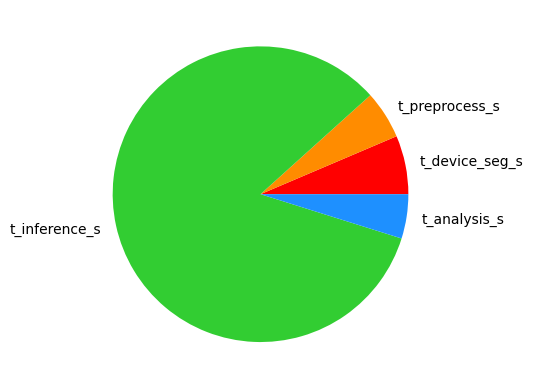

In [16]:
def plot_timing_breakdown(timing_outputs_csv):
    mean_timings = timing_outputs_csv.mean(numeric_only=True).drop(["image_index", "t_job_wall_s", "t_pipeline_s", 'Unnamed: 0'])
    fig, ax = plt.subplots()
    ax.pie(mean_timings, labels = mean_timings.index, colors = ["red", "darkorange", "limegreen", "dodgerblue", "darkviolet"])
    plt.savefig("timing_breakdown_initial.pdf")
    plt.savefig("timing_breakdown_initial.png")
    
plot_timing_breakdown(pd.read_csv("first_attempt_time_check.csv"))



In [38]:
def combine_outputs(root_dir):
    csv_files = list(root_dir.rglob("*.csv"))
    if not csv_files:
        print("No CSV files found.")
        return None, None
    else:
        combined_analysis_metrics = []
        combined_branch_metrics = []
        for f in csv_files:
            try:
                df = pd.read_csv(f)
                df["source_file"] = str(f)
                df["source_folder"] = str(f.parent)
                if "analysis" in str(f):
                    combined_analysis_metrics.append(df)
                elif "branch" in str(f):
                    combined_branch_metrics.append(df)
                else:
                    print(f"Found extra uncategorised csv {f}")
            except Exception as e:
                print(f"Failed to read {f}: {e}")               

        if combined_analysis_metrics:
            combined_analysis_metrics = pd.concat(combined_analysis_metrics, ignore_index=True, sort=False)
            output_file = root_dir / "combined_analysis_metrics.csv"
            combined_analysis_metrics.to_csv(output_file, index=False)
        else:
            print("No analysis metric files could be read successfully.")
            combined_analysis_metrics = None
        if combined_branch_metrics:
            combined_branch_metrics = pd.concat(combined_branch_metrics, ignore_index=True, sort=False)
            output_file = root_dir / "combined_branch_metrics.csv"
            combined_branch_metrics.to_csv(output_file, index=False)
        else:
            print("No branch metric files could be read successfully.")
            combined_branch_metrics = None
        print(f"Total files combined: {len(combined_analysis_metrics)} analysis files and {len(combined_branch_metrics)} branch files")

        return combined_analysis_metrics, combined_branch_metrics

def find_condition(row):
    name = str(row["image_name"]).lower()
    if "static" in name:
        return "static"
    elif "flow" in name:
        return "flow"
    # elif "reservoir" in name:
    #     return "resevoir"
    # elif any(f"valve {n}" in name for n in [1, 2, 7, 8]):
    #     return "high_flow"
    # elif any(f"valve {n}" in name for n in [3, 4, 5, 6]):
    #     return "low_flow"
    else:
        return "NA"
    # return row

def plot_experiment_comparisons(df, y_metrics, xorder, plot_title, root_dir, save_type = "png"):
    fig, ax = plt.subplots(ncols = len(y_metrics), figsize=(4*len(y_metrics),5))
    for i, metric in enumerate(y_metrics):
        print(i, metric)
        sns.swarmplot(data = df, x = "experiment", y = metric, ax = ax[i], zorder = 100, color = "dodgerblue", order = xorder)
        sns.boxplot(data = df, x = "experiment", y = metric, ax = ax[i], fill = False, color = "#000000", order = xorder)
    plt.tight_layout()
    print(f"{root_dir}/{plot_title}.{save_type}")
    plt.savefig(f"{root_dir}/{plot_title}.{save_type}")


In [39]:
root_dir = Path(r"Z:\Bel\Farid_bel\Old_Experiment_Outputs")
combined_analysis_metrics, combined_branch_metrics = combine_outputs(root_dir)
combined_analysis_metrics["experiment"] = combined_analysis_metrics.apply(find_condition, axis=1)
combined_branch_metrics["experiment"] = combined_branch_metrics.apply(find_condition, axis=1)

Found extra uncategorised csv Z:\Bel\Farid_bel\Old_Experiment_Outputs\all_csvs_concatenated.csv
Total files combined: 87 analysis files and 1269642 branch files


0 skeleton_lacunarity
1 internal_pore_area_fraction_in_filled_vascular_area
Z:\Bel\Farid_bel\Old_Experiment_Outputs/test.png


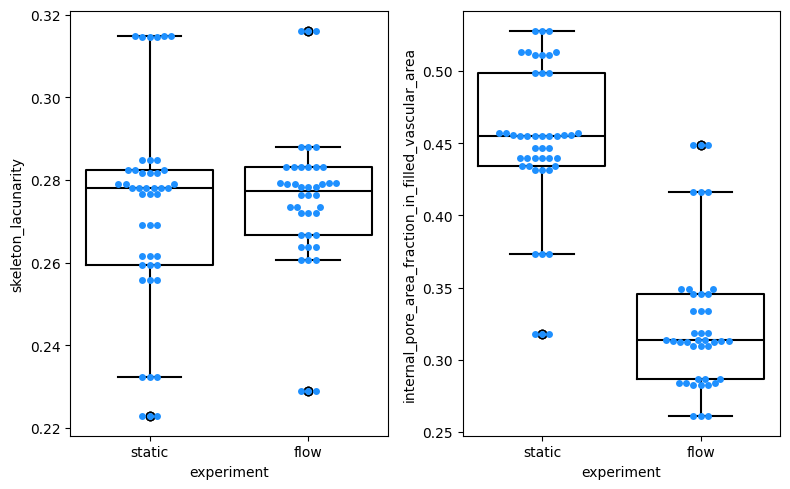

In [40]:
# # xorder = ["static", "resevoir", "low_flow", "high_flow"]
xorder = ["static", "flow"]
plot_experiment_comparisons(combined_analysis_metrics, ["skeleton_lacunarity", "internal_pore_area_fraction_in_filled_vascular_area"], xorder, "test", root_dir)

In [48]:
def pca_plots(combined_analysis_metrics):
    X = combined_analysis_metrics.drop(
        ["experiment", "image_name", "source_file", "image_index",
         "chip_volume_um3", "convex_hull_volume_um3", "vessel_volume_um3", "source_folder"],
        axis=1
    )
    y = combined_analysis_metrics["experiment"]
    
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)
    
    X_train, X_test, y_train, y_test = train_test_split(
        X_pca, y, test_size=0.3, random_state=42
    )

    model = LogisticRegression()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = (y_pred == y_test).mean()

    # PCA loadings and logistic regression feature importance projected back to original features
    loadings = pd.DataFrame(pca.components_, columns=X.columns, index=["PC1", "PC2"])
    feature_importance = (model.coef_ @ pca.components_).flatten()
    feat_imp = pd.Series(feature_importance, index=X.columns).sort_values(key=abs, ascending=False)

    # Derive class labels and colour map from the data
    labels, uniques = pd.factorize(y)
    class_colors = {0: "tab:red", 1: "tab:blue"}

    # Width ratios: give the loadings heatmap (position 2) ~3x the space
    fig, axes = plt.subplots(ncols=4, figsize=(32, 8),
                             gridspec_kw={"width_ratios": [1, 1, 3, 1.5]})

    # --- 1. PCA scatter ---
    for idx, name in enumerate(uniques):
        mask = labels == idx
        axes[0].scatter(
            X_pca[mask, 0], X_pca[mask, 1],
            c=class_colors[idx], label=name.capitalize(),
            s=80, edgecolors="k", linewidths=0.4, alpha=0.8
        )
    axes[0].set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} var.)")
    axes[0].set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} var.)")
    axes[0].set_title("PCA – first two components")
    axes[0].legend()

    # --- 2. Confusion matrix ---
    cm = confusion_matrix(y_test, y_pred, labels=uniques)
    tick_labels = [u.capitalize() for u in uniques]
    sns.heatmap(cm, annot=True, fmt="d",
                xticklabels=tick_labels, yticklabels=tick_labels,
                ax=axes[1], cmap="Blues")
    axes[1].set_xlabel("Predicted")
    axes[1].set_ylabel("True")
    axes[1].set_title(f"Confusion matrix (acc = {accuracy:.0%})")

    # --- 3. PCA loadings heatmap ---
    sns.heatmap(loadings, annot=True, fmt=".1f", ax=axes[2], cmap="coolwarm", center=0)
    axes[2].set_title("PCA loadings")
    axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=45, ha="right")

    # --- 4. Top feature importances ---
    top = feat_imp.head(10)
    colors = ["tab:blue" if v > 0 else "tab:red" for v in top]
    # Reverse both bars and colours together so largest magnitude is at top
    axes[3].barh(top.index[::-1], top.values[::-1], color=colors[::-1])
    axes[3].set_xlabel("Coefficient (positive → flow, negative → static)")
    axes[3].set_title("Top 10 discriminating features")
    axes[3].axvline(0, color="grey", linewidth=0.8)

    plt.tight_layout()
    plt.show()

    print(f"Test accuracy: {accuracy:.2%}  ({len(y_test)} samples)")


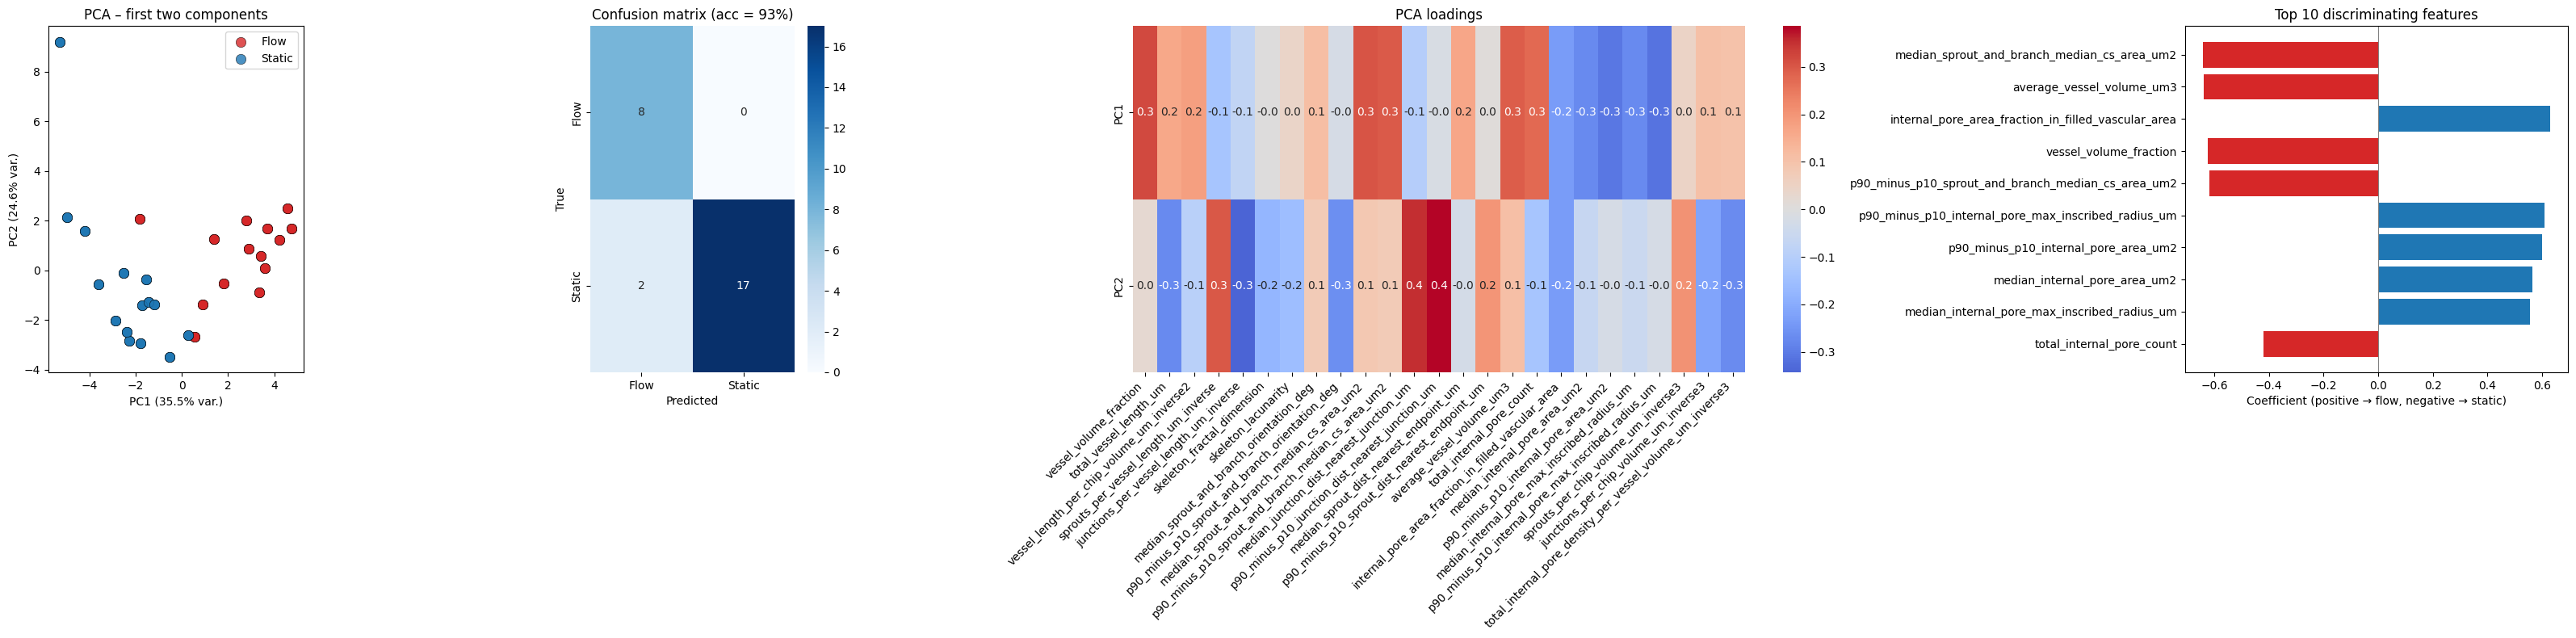

Test accuracy: 92.59%  (27 samples)


In [49]:
pca_plots(combined_analysis_metrics)

In [ ]:
import shap
from sklearn.ensemble import GradientBoostingClassifier
from itertools import combinations

def shap_analysis(combined_analysis_metrics):
    drop_cols = ["experiment", "image_name", "source_file", "image_index",
                 "chip_volume_um3", "convex_hull_volume_um3", "vessel_volume_um3", "source_folder"]
    X = combined_analysis_metrics.drop(drop_cols, axis=1)
    y = (combined_analysis_metrics["experiment"] == "flow").astype(int)  # 1 = flow, 0 = static

    # Gradient boosted tree — captures nonlinear interactions natively
    model = GradientBoostingClassifier(n_estimators=200, max_depth=4, random_state=42)
    model.fit(X, y)

    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X)

    # ---------- 1. Summary: single-feature importance with directionality ----------
    fig, ax = plt.subplots(figsize=(8, 6))
    shap.summary_plot(shap_values, X, show=False, max_display=15)
    plt.title("SHAP summary – each dot is one sample\nRight = pushes toward flow, Left= pushes toward static")
    plt.tight_layout()
    plt.show()

    # ---------- 2. Mean absolute SHAP bar chart ----------
    fig, ax = plt.subplots(figsize=(8, 5))
    shap.summary_plot(shap_values, X, plot_type="bar", show=False, max_display=15)
    plt.title("Mean |SHAP| – overall feature importance")
    plt.tight_layout()
    plt.show()

    # ---------- 3. Top interaction effects ----------
    shap_interaction = explainer.shap_interaction_values(X)

    n_features = X.shape[1]
    interaction_strengths = {}
    for i, j in combinations(range(n_features), 2):
        strength = np.abs(shap_interaction[:, i, j]).mean()
        interaction_strengths[(X.columns[i], X.columns[j])] = strength

    top_interactions = sorted(interaction_strengths.items(), key=lambda x: x[1], reverse=True)[:10]

    # Bar chart of top interactions
    labels = [f"{a}\n× {b}" for (a, b), _ in top_interactions]
    values = [v for _, v in top_interactions]

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.barh(labels[::-1], values[::-1], color="mediumpurple")
    ax.set_xlabel("Mean |SHAP interaction value|")
    ax.set_title("Top 10 feature interactions separating static vs flow")
    plt.tight_layout()
    plt.show()

    # ---------- 4. Dependence plots for top 3 interactions ----------
    for (feat_a, feat_b), _ in top_interactions[:3]:
        fig, ax = plt.subplots(figsize=(7, 5))
        shap.dependence_plot(feat_a, shap_values, X, interaction_index=feat_b, show=False, ax=ax)
        ax.set_title(f"Interaction: {feat_a} × {feat_b}")
        plt.tight_layout()
        plt.show()

    return model, shap_values, shap_interaction

# Colour on the right	Meaning
# Red dots clustered right	High values of this feature → predicts flow
# Blue dots clustered right	Low values of this feature → predicts flow
# Red dots clustered left	High values → predicts static
# Blue dots clustered left	Low values → predicts static

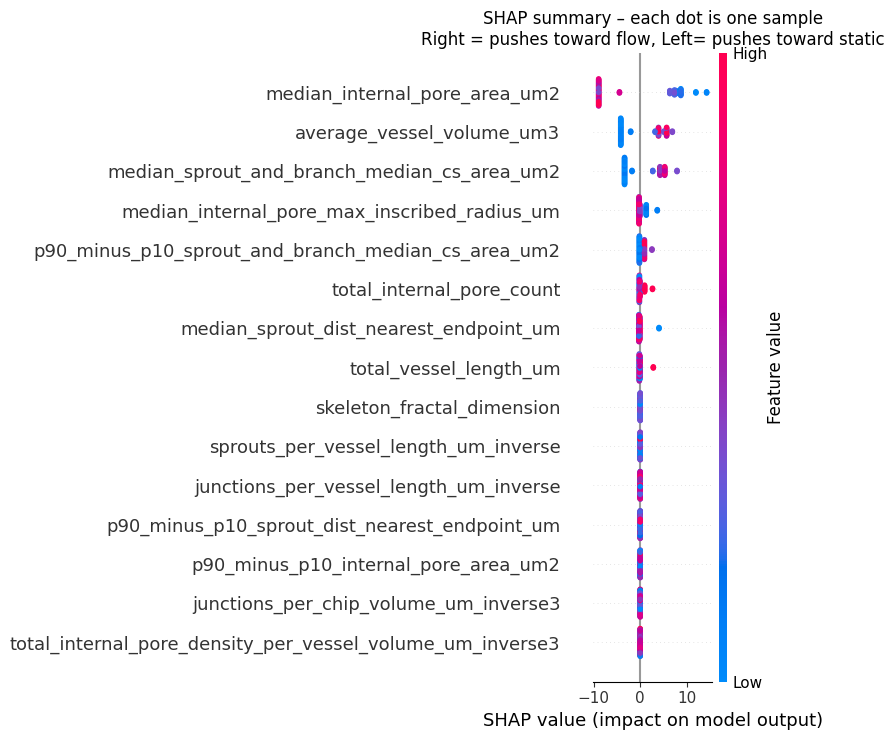

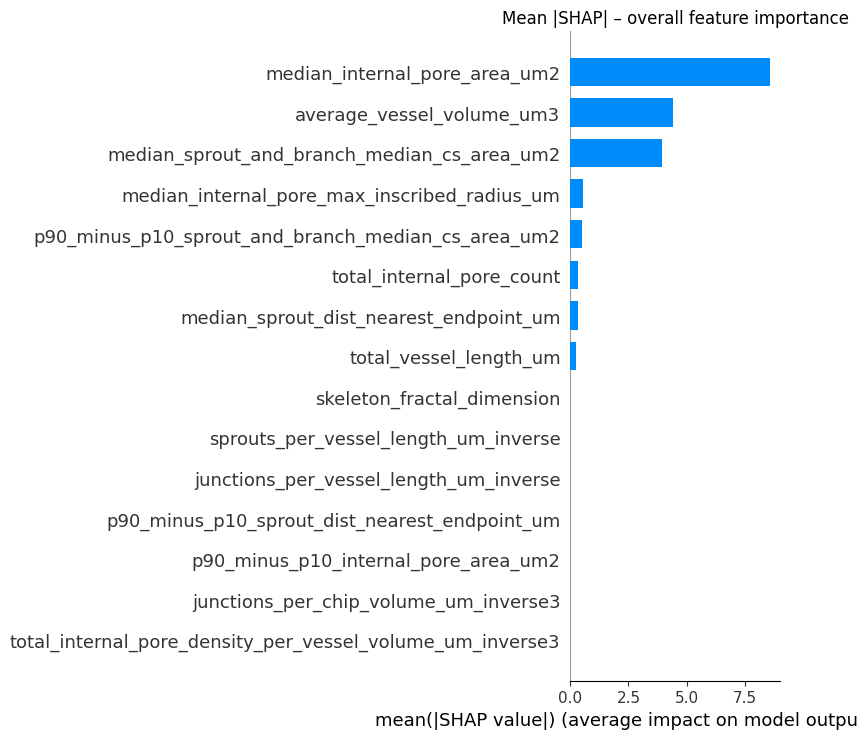

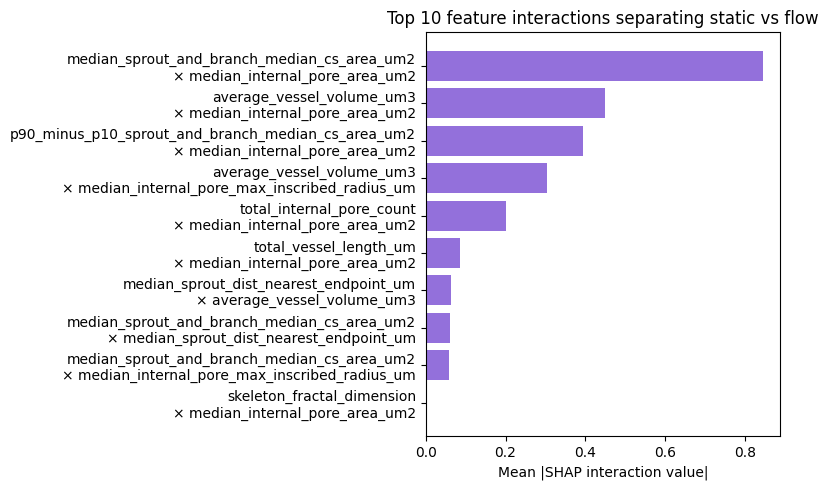

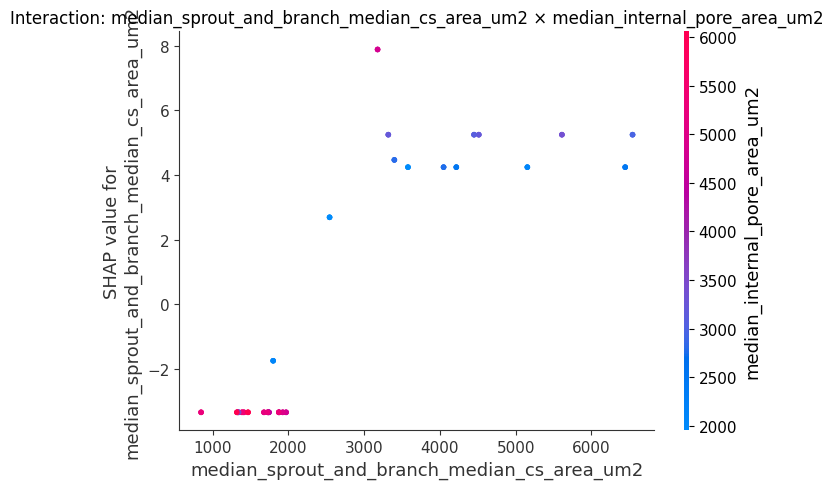

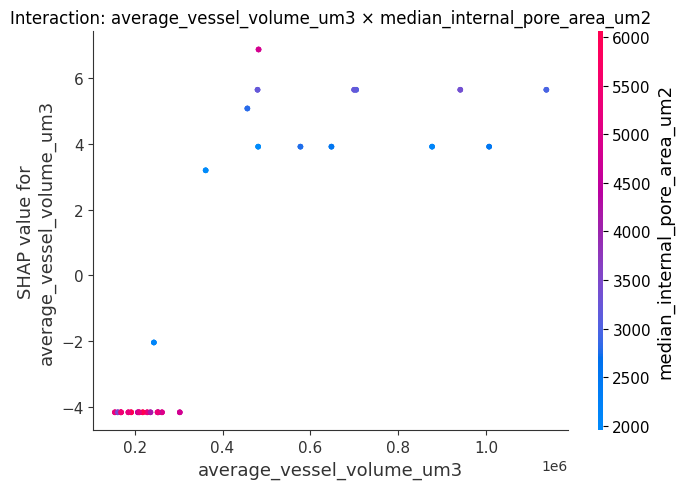

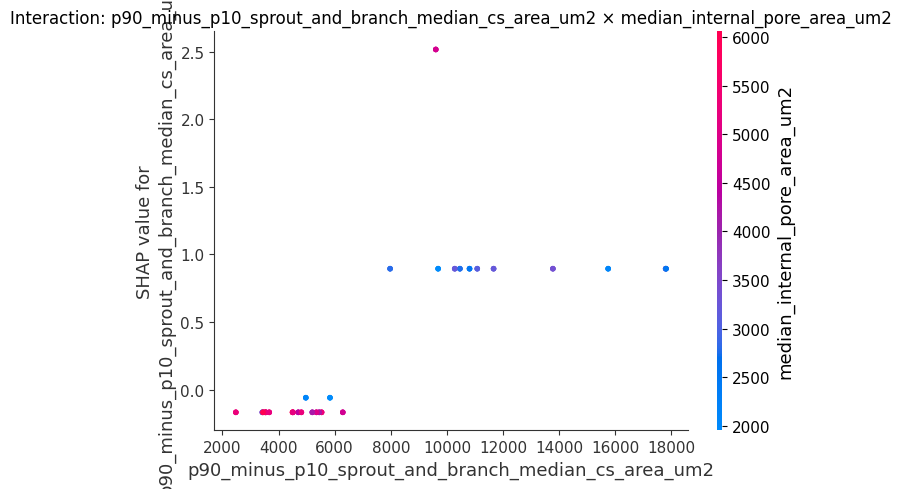

In [53]:
model, shap_values, shap_interaction = shap_analysis(combined_analysis_metrics)

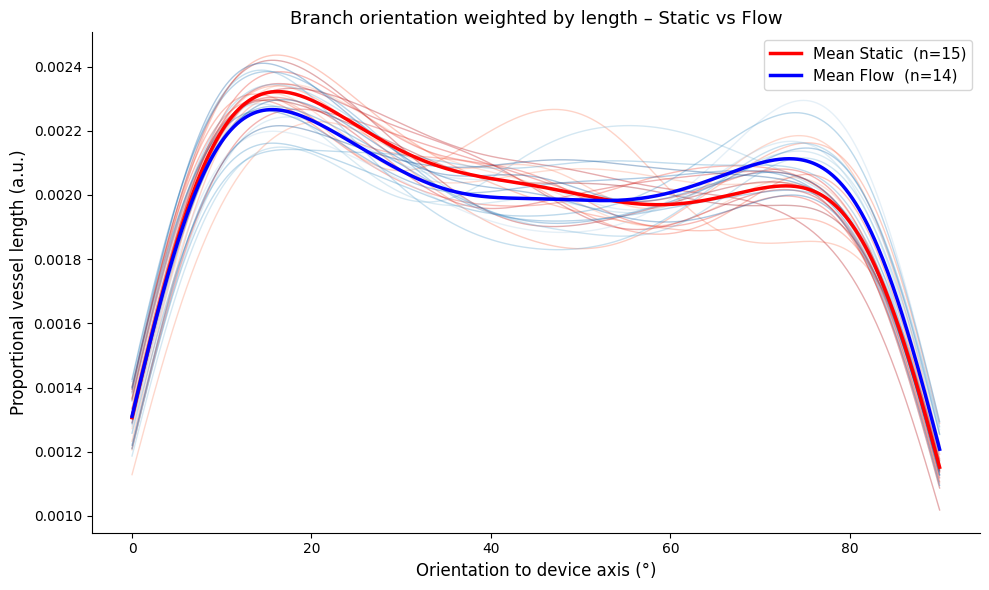

In [54]:




# Filter to valid data
plot_df = combined_branch_metrics.dropna(subset=["orientation_to_device_axis_deg", "path_length_um"]).copy()
plot_df = plot_df[plot_df["experiment"].isin(["static", "flow"])]

# Shared x-axis for evaluation
x_eval = np.linspace(plot_df["orientation_to_device_axis_deg"].min(),
                      plot_df["orientation_to_device_axis_deg"].max(), 500)

# Colour maps: shades of red for static, shades of blue for flow
from matplotlib.cm import Reds, Blues

static_images = sorted(plot_df[plot_df["experiment"] == "static"]["image_name"].unique())
flow_images   = sorted(plot_df[plot_df["experiment"] == "flow"]["image_name"].unique())

static_colors = [Reds(0.3 + 0.6 * i / max(len(static_images) - 1, 1)) for i in range(len(static_images))]
flow_colors   = [Blues(0.3 + 0.6 * i / max(len(flow_images) - 1, 1))   for i in range(len(flow_images))]

fig, ax = plt.subplots(figsize=(10, 6))

# Store KDE values for computing the mean curve
static_kdes = []
flow_kdes   = []

# --- Per-image length-weighted KDE ---
for img_name, color in zip(static_images, static_colors):
    sub = plot_df[plot_df["image_name"] == img_name]
    angles  = sub["orientation_to_device_axis_deg"].values
    lengths = sub["path_length_um"].values
    weights = lengths / lengths.sum()          # normalise weights
    kde = gaussian_kde(angles, weights=weights, bw_method=0.3)
    y = kde(x_eval)
    y = y / y.sum()                            # normalise area so curves are comparable
    ax.plot(x_eval, y, color=color, alpha=0.35, linewidth=1)
    static_kdes.append(y)

for img_name, color in zip(flow_images, flow_colors):
    sub = plot_df[plot_df["image_name"] == img_name]
    angles  = sub["orientation_to_device_axis_deg"].values
    lengths = sub["path_length_um"].values
    weights = lengths / lengths.sum()
    kde = gaussian_kde(angles, weights=weights, bw_method=0.3)
    y = kde(x_eval)
    y = y / y.sum()
    ax.plot(x_eval, y, color=color, alpha=0.35, linewidth=1)
    flow_kdes.append(y)

# --- Mean curves ---
mean_static = np.mean(static_kdes, axis=0)
mean_flow   = np.mean(flow_kdes, axis=0)

ax.plot(x_eval, mean_static, color="red",  linewidth=2.5, label=f"Mean Static  (n={len(static_images)})")
ax.plot(x_eval, mean_flow,   color="blue", linewidth=2.5, label=f"Mean Flow  (n={len(flow_images)})")

ax.set_xlabel("Orientation to device axis (°)", fontsize=12)
ax.set_ylabel("Proportional vessel length (a.u.)", fontsize=12)
ax.set_title("Branch orientation weighted by length – Static vs Flow", fontsize=13)
ax.legend(fontsize=11)
sns.despine()
plt.tight_layout()
plt.show()

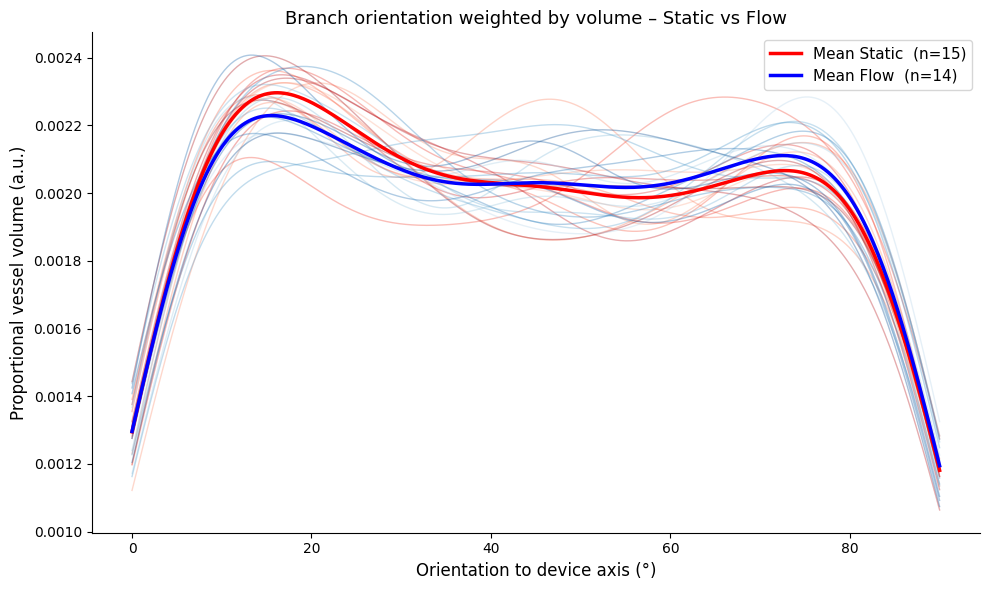

In [55]:
# --- Same plot but weighted by branch VOLUME instead of length ---
vol_df = combined_branch_metrics.dropna(subset=["orientation_to_device_axis_deg", "branch_volume_um3"]).copy()
vol_df = vol_df[vol_df["experiment"].isin(["static", "flow"])]

x_eval_v = np.linspace(vol_df["orientation_to_device_axis_deg"].min(),
                        vol_df["orientation_to_device_axis_deg"].max(), 500)

static_images_v = sorted(vol_df[vol_df["experiment"] == "static"]["image_name"].unique())
flow_images_v   = sorted(vol_df[vol_df["experiment"] == "flow"]["image_name"].unique())

static_colors_v = [Reds(0.3 + 0.6 * i / max(len(static_images_v) - 1, 1)) for i in range(len(static_images_v))]
flow_colors_v   = [Blues(0.3 + 0.6 * i / max(len(flow_images_v) - 1, 1))   for i in range(len(flow_images_v))]

fig, ax = plt.subplots(figsize=(10, 6))

static_kdes_v = []
flow_kdes_v   = []

for img_name, color in zip(static_images_v, static_colors_v):
    sub = vol_df[vol_df["image_name"] == img_name]
    angles  = sub["orientation_to_device_axis_deg"].values
    volumes = sub["branch_volume_um3"].values
    weights = volumes / volumes.sum()
    kde = gaussian_kde(angles, weights=weights, bw_method=0.3)
    y = kde(x_eval_v)
    y = y / y.sum()
    ax.plot(x_eval_v, y, color=color, alpha=0.35, linewidth=1)
    static_kdes_v.append(y)

for img_name, color in zip(flow_images_v, flow_colors_v):
    sub = vol_df[vol_df["image_name"] == img_name]
    angles  = sub["orientation_to_device_axis_deg"].values
    volumes = sub["branch_volume_um3"].values
    weights = volumes / volumes.sum()
    kde = gaussian_kde(angles, weights=weights, bw_method=0.3)
    y = kde(x_eval_v)
    y = y / y.sum()
    ax.plot(x_eval_v, y, color=color, alpha=0.35, linewidth=1)
    flow_kdes_v.append(y)

mean_static_v = np.mean(static_kdes_v, axis=0)
mean_flow_v   = np.mean(flow_kdes_v, axis=0)

ax.plot(x_eval_v, mean_static_v, color="red",  linewidth=2.5, label=f"Mean Static  (n={len(static_images_v)})")
ax.plot(x_eval_v, mean_flow_v,   color="blue", linewidth=2.5, label=f"Mean Flow  (n={len(flow_images_v)})")

ax.set_xlabel("Orientation to device axis (°)", fontsize=12)
ax.set_ylabel("Proportional vessel volume (a.u.)", fontsize=12)
ax.set_title("Branch orientation weighted by volume – Static vs Flow", fontsize=13)
ax.legend(fontsize=11)
sns.despine()
plt.tight_layout()
plt.show()